# Machine Learning Regularization: Complete Guide
## Bias-Variance Tradeoff, L1, L2 & Elastic Net Regularization

**Created by:** Mahipal Singh Sr - Instructor and Mentor DS/AI/ML  
**Purpose:** Comprehensive educational guide for understanding regularization techniques in machine learning  
**Level:** Intermediate to Advanced

## Table of Contents
1. Bias-Variance Tradeoff Concept
2. L1 Regularization (Lasso)
3. L2 Regularization (Ridge)
4. Elastic Net (L1 + L2)
5. End-to-End Use Case
6. Model Comparison & Evaluation
7. Visualizations & Insights

# 1. BIAS-VARIANCE TRADEOFF

## Concept Explanation

The bias-variance tradeoff is a fundamental concept in machine learning that describes the tension between:

### **BIAS**
- Error from overly simplistic models that make strong assumptions
- Models that UNDERFIT the data
- High bias means model is too simple to capture patterns
- Example: Fitting a linear model to non-linear data

### **VARIANCE**
- Error from overly complex models that are too sensitive to training data fluctuations
- Models that OVERFIT the data
- High variance means model captures noise, not real patterns
- Example: High-degree polynomial fitting every data point

### **TRADEOFF**
- As model complexity increases: Bias decreases, Variance increases
- Goal: Find the sweet spot that minimizes Total Error
- Total Error = Bias2 + Variance + Irreducible Error
- Regularization helps us control this tradeoff

In [1]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('[OK] All libraries imported successfully!')

[OK] All libraries imported successfully!


## Visualizing Bias-Variance Tradeoff

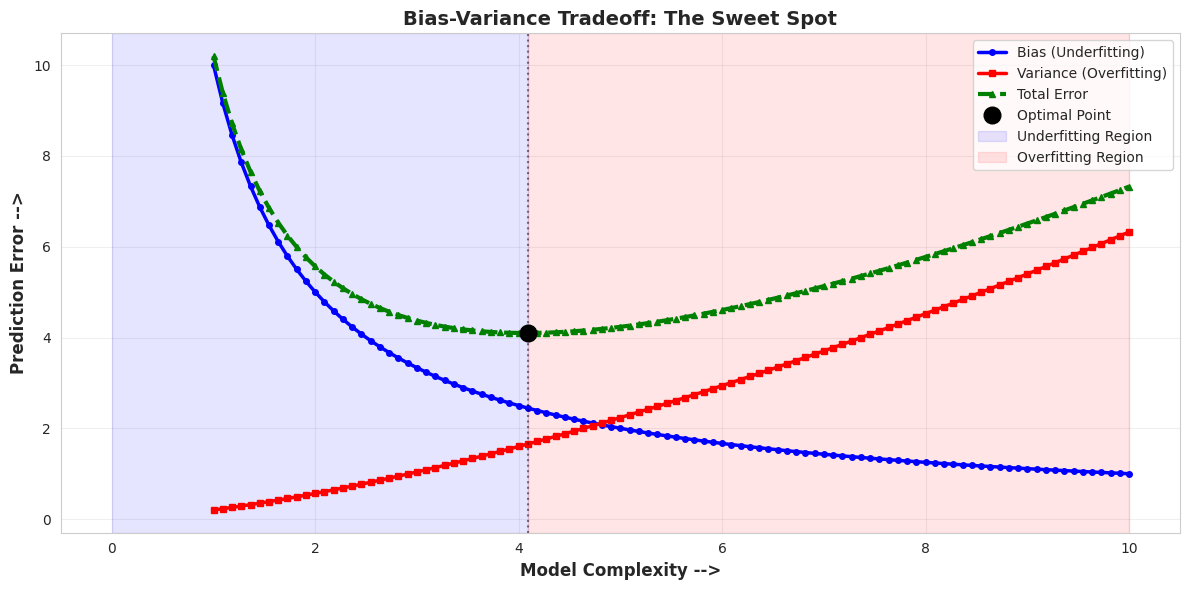

[RESULTS]
Optimal Model Complexity: 4.09
Minimum Total Error: 4.10


In [2]:
# Create a visual representation of bias-variance tradeoff
# This plot shows how error changes with model complexity
model_complexity = np.linspace(1, 10, 100)

# Simulate error curves
# Bias decreases as model complexity increases
bias = 10 / model_complexity
# Variance increases as model complexity increases (overfitting risk)
variance = model_complexity ** 1.5 / 5
# Total error is the sum of both
total_error = bias + variance

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(model_complexity, bias, 'b-', linewidth=2.5, label='Bias (Underfitting)', marker='o', markersize=4)
plt.plot(model_complexity, variance, 'r-', linewidth=2.5, label='Variance (Overfitting)', marker='s', markersize=4)
plt.plot(model_complexity, total_error, 'g--', linewidth=3, label='Total Error', marker='^', markersize=5)

# Mark the optimal point
optimal_idx = np.argmin(total_error)
optimal_complexity = model_complexity[optimal_idx]
optimal_error = total_error[optimal_idx]
plt.plot(optimal_complexity, optimal_error, 'ko', markersize=12, label='Optimal Point')
plt.axvline(optimal_complexity, color='k', linestyle=':', alpha=0.5)

# Add regions
plt.axvspan(0, optimal_complexity, alpha=0.1, color='blue', label='Underfitting Region')
plt.axvspan(optimal_complexity, 10, alpha=0.1, color='red', label='Overfitting Region')

plt.xlabel('Model Complexity -->', fontsize=12, fontweight='bold')
plt.ylabel('Prediction Error -->', fontsize=12, fontweight='bold')
plt.title('Bias-Variance Tradeoff: The Sweet Spot', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('[RESULTS]')
print(f'Optimal Model Complexity: {optimal_complexity:.2f}')
print(f'Minimum Total Error: {optimal_error:.2f}')

---
# 2. L1 REGULARIZATION (LASSO)

## Mathematical Concept

**Loss Function:** MSE + lambda * Sigma(|weights|)

Where:
- MSE = Mean Squared Error
- lambda = Regularization strength (higher lambda = more regularization)
- Sigma(|weights|) = Sum of absolute values of all coefficients (L1 norm)

## Key Characteristics:
- **Feature Selection:** Can shrink some coefficients to EXACTLY ZERO
- **Sparse Solutions:** Results in sparse models with fewer features
- **Robust:** Less sensitive to outliers compared to Ridge
- **Use Case:** When you want to identify important features

## Geometric Interpretation:
- L1 penalty creates a diamond-shaped constraint region
- Solution often hits corners of the diamond (sparse solution)

In [3]:
# Create synthetic dataset for demonstration
np.random.seed(42)
X = np.random.randn(100, 2)  # 100 samples, 2 features
# y depends mostly on first feature, second feature has less importance
y = 3*X[:, 0] + 0.5*X[:, 1] + np.random.randn(100)*0.5

# Lasso Regression Example
# alpha is the regularization parameter (lambda)
lasso = Lasso(alpha=0.1)
lasso.fit(X, y)

print('[LASSO REGRESSION RESULTS]')
print(f'Feature 1 Coefficient: {lasso.coef_[0]:.4f}')
print(f'Feature 2 Coefficient: {lasso.coef_[1]:.4f}')
print(f'Intercept: {lasso.intercept_:.4f}')
print(f'Training R2 Score: {lasso.score(X, y):.4f}')

# Try with higher regularization
lasso_strong = Lasso(alpha=1.0)  # Stronger regularization
lasso_strong.fit(X, y)

print('[LASSO WITH STRONGER REGULARIZATION (alpha=1.0)]')
print(f'Feature 1 Coefficient: {lasso_strong.coef_[0]:.4f}')
print(f'Feature 2 Coefficient: {lasso_strong.coef_[1]:.4f}')
print(f'Training R2 Score: {lasso_strong.score(X, y):.4f}')

print('[OBSERVATION]')
print('Notice how Feature 2 coefficient shrinks as regularization increases!')

[LASSO REGRESSION RESULTS]
Feature 1 Coefficient: 2.9613
Feature 2 Coefficient: 0.3164
Intercept: 0.0342
Training R2 Score: 0.9598
[LASSO WITH STRONGER REGULARIZATION (alpha=1.0)]
Feature 1 Coefficient: 1.7334
Feature 2 Coefficient: 0.0000
Training R2 Score: 0.7559
[OBSERVATION]
Notice how Feature 2 coefficient shrinks as regularization increases!


---
# 3. L2 REGULARIZATION (RIDGE)

## Mathematical Concept

**Loss Function:** MSE + lambda * Sigma(weights^2)

Where:
- MSE = Mean Squared Error
- lambda = Regularization strength
- Sigma(weights^2) = Sum of squared coefficients (L2 norm)

## Key Characteristics:
- **Shrinkage:** Reduces coefficient magnitudes but RARELY sets them to zero
- **Dense Solutions:** Keeps all features in the model
- **Multicollinearity:** Handles correlated features better than L1
- **Use Case:** When you want to keep all features but reduce their influence

## Geometric Interpretation:
- L2 penalty creates a circular constraint region
- Solution usually does not hit corners (hence, non-sparse)
- Smooth shrinkage of coefficients

In [4]:
# Ridge Regression Example
# alpha is the regularization parameter (lambda)
ridge = Ridge(alpha=0.1)
ridge.fit(X, y)

print('[RIDGE REGRESSION RESULTS]')
print(f'Feature 1 Coefficient: {ridge.coef_[0]:.4f}')
print(f'Feature 2 Coefficient: {ridge.coef_[1]:.4f}')
print(f'Intercept: {ridge.intercept_:.4f}')
print(f'Training R2 Score: {ridge.score(X, y):.4f}')

# Try with higher regularization
ridge_strong = Ridge(alpha=1.0)  # Stronger regularization
ridge_strong.fit(X, y)

print('[RIDGE WITH STRONGER REGULARIZATION (alpha=1.0)]')
print(f'Feature 1 Coefficient: {ridge_strong.coef_[0]:.4f}')
print(f'Feature 2 Coefficient: {ridge_strong.coef_[1]:.4f}')
print(f'Training R2 Score: {ridge_strong.score(X, y):.4f}')

print('[OBSERVATION]')
print('Ridge shrinks coefficients but keeps them NON-ZERO!')

[RIDGE REGRESSION RESULTS]
Feature 1 Coefficient: 3.0911
Feature 2 Coefficient: 0.4136
Intercept: 0.0459
Training R2 Score: 0.9629
[RIDGE WITH STRONGER REGULARIZATION (alpha=1.0)]
Feature 1 Coefficient: 3.0534
Feature 2 Coefficient: 0.4109
Training R2 Score: 0.9627
[OBSERVATION]
Ridge shrinks coefficients but keeps them NON-ZERO!


## Comparison: L1 vs L2

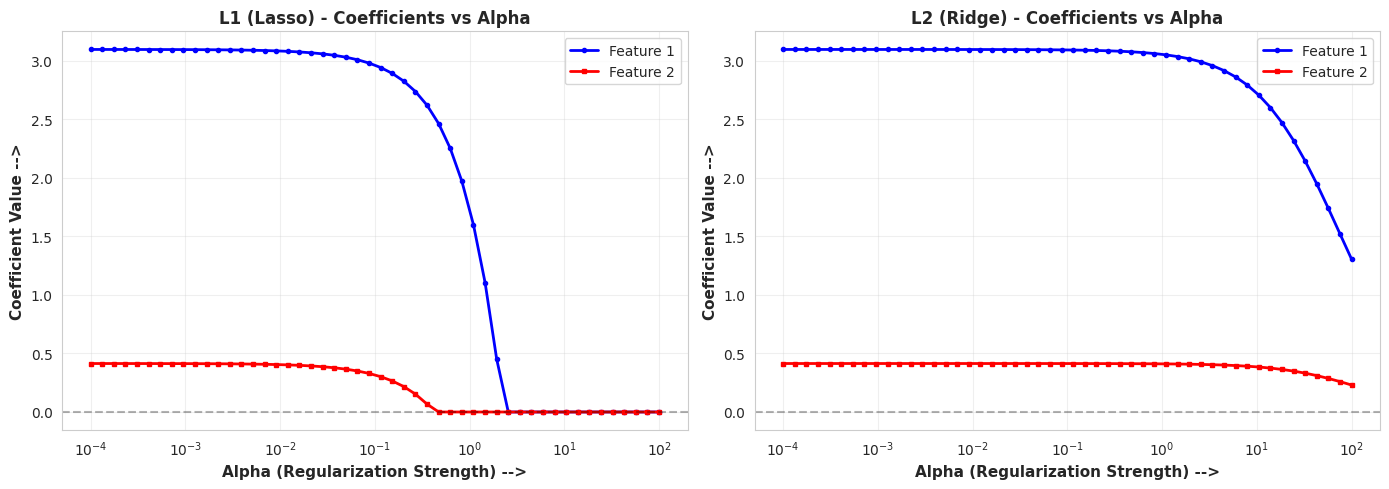

[KEY INSIGHTS]
1. L1 (Lasso): Feature 2 coefficient goes to ZERO at high alpha (feature selection)
2. L2 (Ridge): Both coefficients shrink but NEVER reach zero (smooth shrinkage)


In [5]:
# Compare L1 and L2 with different alpha values
# Range of alpha values from 0.0001 to 100
alphas = np.logspace(-4, 2, 50)
lasso_coefs = []
ridge_coefs = []

# Fit models with different alphas
for alpha in alphas:
    # Lasso
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X, y)
    lasso_coefs.append(lasso_model.coef_)

    # Ridge
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X, y)
    ridge_coefs.append(ridge_model.coef_)

lasso_coefs = np.array(lasso_coefs)
ridge_coefs = np.array(ridge_coefs)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lasso coefficients
axes[0].plot(alphas, lasso_coefs[:, 0], 'b-', linewidth=2, label='Feature 1', marker='o', markersize=3)
axes[0].plot(alphas, lasso_coefs[:, 1], 'r-', linewidth=2, label='Feature 2', marker='s', markersize=3)
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].set_xlabel('Alpha (Regularization Strength) -->', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Coefficient Value -->', fontsize=11, fontweight='bold')
axes[0].set_title('L1 (Lasso) - Coefficients vs Alpha', fontsize=12, fontweight='bold')
axes[0].set_xscale('log')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Ridge coefficients
axes[1].plot(alphas, ridge_coefs[:, 0], 'b-', linewidth=2, label='Feature 1', marker='o', markersize=3)
axes[1].plot(alphas, ridge_coefs[:, 1], 'r-', linewidth=2, label='Feature 2', marker='s', markersize=3)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Alpha (Regularization Strength) -->', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Coefficient Value -->', fontsize=11, fontweight='bold')
axes[1].set_title('L2 (Ridge) - Coefficients vs Alpha', fontsize=12, fontweight='bold')
axes[1].set_xscale('log')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('[KEY INSIGHTS]')
print('1. L1 (Lasso): Feature 2 coefficient goes to ZERO at high alpha (feature selection)')
print('2. L2 (Ridge): Both coefficients shrink but NEVER reach zero (smooth shrinkage)')

---
# 4. ELASTIC NET (L1 + L2)

## Mathematical Concept

**Loss Function:** MSE + lambda1 * Sigma(|weights|) + lambda2 * Sigma(weights^2)

Or more commonly:
**Loss Function:** MSE + lambda * [alpha * Sigma(|weights|) + (1-alpha) * Sigma(weights^2)]

Where:
- lambda = Overall regularization strength
- alpha = Balance parameter (0 to 1)
  - alpha = 0 --> Pure Ridge (L2)
  - alpha = 1 --> Pure Lasso (L1)
  - 0 < alpha < 1 --> Combination of both

## Key Characteristics:
- **Best of Both:** Combines feature selection (L1) with coefficient shrinkage (L2)
- **Handles Multicollinearity:** Better than pure Lasso
- **Flexible:** Balance between sparse and dense solutions
- **Use Case:** When you want some feature selection but also handle correlated features

## When to Use:
- Multiple correlated features
- Want automatic feature selection
- Need a robust model

In [6]:
# Elastic Net Regression Example
# alpha=regularization, l1_ratio=balance (0.5 = 50% L1, 50% L2)
elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.5)
elasticnet.fit(X, y)

print('[ELASTIC NET RESULTS (l1_ratio=0.5)]')
print(f'Feature 1 Coefficient: {elasticnet.coef_[0]:.4f}')
print(f'Feature 2 Coefficient: {elasticnet.coef_[1]:.4f}')
print(f'Intercept: {elasticnet.intercept_:.4f}')
print(f'Training R2 Score: {elasticnet.score(X, y):.4f}')

# Try with more L1 emphasis
elasticnet_l1 = ElasticNet(alpha=0.1, l1_ratio=0.9)  # 90% L1, 10% L2
elasticnet_l1.fit(X, y)

print('[ELASTIC NET (MORE L1 EMPHASIS, l1_ratio=0.9)]')
print(f'Feature 1 Coefficient: {elasticnet_l1.coef_[0]:.4f}')
print(f'Feature 2 Coefficient: {elasticnet_l1.coef_[1]:.4f}')
print(f'Training R2 Score: {elasticnet_l1.score(X, y):.4f}')

# Try with more L2 emphasis
elasticnet_l2 = ElasticNet(alpha=0.1, l1_ratio=0.1)  # 10% L1, 90% L2
elasticnet_l2.fit(X, y)

print('[ELASTIC NET (MORE L2 EMPHASIS, l1_ratio=0.1)]')
print(f'Feature 1 Coefficient: {elasticnet_l2.coef_[0]:.4f}')
print(f'Feature 2 Coefficient: {elasticnet_l2.coef_[1]:.4f}')
print(f'Training R2 Score: {elasticnet_l2.score(X, y):.4f}')

print('[OBSERVATION]')
print('Elastic Net allows us to balance between L1 and L2 properties!')

[ELASTIC NET RESULTS (l1_ratio=0.5)]
Feature 1 Coefficient: 2.8336
Feature 2 Coefficient: 0.3527
Intercept: 0.0182
Training R2 Score: 0.9556
[ELASTIC NET (MORE L1 EMPHASIS, l1_ratio=0.9)]
Feature 1 Coefficient: 2.9344
Feature 2 Coefficient: 0.3240
Training R2 Score: 0.9592
[ELASTIC NET (MORE L2 EMPHASIS, l1_ratio=0.1)]
Feature 1 Coefficient: 2.7428
Feature 2 Coefficient: 0.3790
Training R2 Score: 0.9505
[OBSERVATION]
Elastic Net allows us to balance between L1 and L2 properties!


---
# 5. END-TO-END USE CASE: HOUSING PRICE PREDICTION

## Problem Statement:
Predict house prices using multiple features with regularization to prevent overfitting

## Dataset:
Boston Housing Dataset (real-world data)
- 506 samples
- 13 features (crime rate, rooms, age, distance, tax, etc.)
- Target: Median house value

In [7]:
# Load Boston Housing dataset
# Note: Using alternative since sklearn Boston dataset is deprecated
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

# Create a DataFrame for better visibility
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df = pd.DataFrame(X, columns=feature_names)
df['PRICE'] = y

print('[BOSTON HOUSING DATASET]')
print(f'Shape: {df.shape}')
print(f'\nFirst few rows:')
print(df.head())
print(f'\nDataset Statistics:')
print(df.describe())

[BOSTON HOUSING DATASET]
Shape: (506, 14)

First few rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  

Dataset Statistics:
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.32245

In [8]:
# Data Preprocessing
# Step 1: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('[DATA SPLITTING]')
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

# Step 2: Standardize features (IMPORTANT for regularization!)
# Regularization penalizes feature magnitudes, so we need to normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('[FEATURE STANDARDIZATION]')
print(f'Features have been standardized (mean=0, std=1)')
print(f'Mean of scaled training features: {X_train_scaled.mean():.6f}')
print(f'Std of scaled training features: {X_train_scaled.std():.6f}')

[DATA SPLITTING]
Training set: 404 samples
Test set: 102 samples
[FEATURE STANDARDIZATION]
Features have been standardized (mean=0, std=1)
Mean of scaled training features: 0.000000
Std of scaled training features: 1.000000


In [9]:
# Train all four models
print('[TRAINING MODELS]')
print('')

# 1. Linear Regression (No Regularization - Baseline)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_train_pred = lr.predict(X_train_scaled)
lr_test_pred = lr.predict(X_test_scaled)

# 2. Ridge Regression (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

# 3. Lasso Regression (L1)
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

# 4. Elastic Net (L1 + L2)
elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
elasticnet.fit(X_train_scaled, y_train)
en_train_pred = elasticnet.predict(X_train_scaled)
en_test_pred = elasticnet.predict(X_test_scaled)

print('[COMPLETION] All models trained successfully!')

[TRAINING MODELS]

[COMPLETION] All models trained successfully!


---
# 6. MODEL EVALUATION & COMPARISON

## Evaluation Metrics:
- **MSE (Mean Squared Error):** Lower is better. Penalizes large errors
- **RMSE (Root Mean Squared Error):** Same unit as target. Easier to interpret
- **MAE (Mean Absolute Error):** Less sensitive to outliers
- **R2 Score:** How much variance is explained (0-1). Higher is better

In [10]:
# Calculate metrics for all models
def calculate_metrics(y_true_train, y_pred_train, y_true_test, y_pred_test, model_name):
    # Training metrics
    train_mse = mean_squared_error(y_true_train, y_pred_train)
    train_rmse = np.sqrt(train_mse)
    train_mae = mean_absolute_error(y_true_train, y_pred_train)
    train_r2 = r2_score(y_true_train, y_pred_train)

    # Test metrics
    test_mse = mean_squared_error(y_true_test, y_pred_test)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_true_test, y_pred_test)
    test_r2 = r2_score(y_true_test, y_pred_test)

    return {
        'Model': model_name,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train R2': train_r2,
        'Test R2': test_r2
    }

# Calculate metrics for all models
results = []
results.append(calculate_metrics(y_train, lr_train_pred, y_test, lr_test_pred, 'Linear Regression'))
results.append(calculate_metrics(y_train, ridge_train_pred, y_test, ridge_test_pred, 'Ridge (L2)'))
results.append(calculate_metrics(y_train, lasso_train_pred, y_test, lasso_test_pred, 'Lasso (L1)'))
results.append(calculate_metrics(y_train, en_train_pred, y_test, en_test_pred, 'Elastic Net (L1+L2)'))

# Create results dataframe
results_df = pd.DataFrame(results)
print('[MODEL EVALUATION RESULTS]')
print(results_df.to_string(index=False))

[MODEL EVALUATION RESULTS]
              Model  Train MSE  Test MSE  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R2  Test R2
  Linear Regression  21.641413 24.291119    4.652033   4.928602   3.314772  3.189092  0.750886 0.668759
         Ridge (L2)  21.642751 24.312904    4.652177   4.930812   3.308708  3.185724  0.750870 0.668462
         Lasso (L1)  22.149497 25.656739    4.706325   5.065248   3.265766  3.241803  0.745037 0.650138
Elastic Net (L1+L2)  22.181599 25.203553    4.709734   5.020314   3.256227  3.192091  0.744668 0.656317


In [11]:
# Detailed comparison with formatting
print('\n' + '='*80)
print('DETAILED MODEL COMPARISON')
print('='*80)

for idx, result in enumerate(results):
    print(f'\n{idx+1}. {result["Model"].upper()}')
    print('-' * 80)
    print(f'   TRAINING Performance:')
    print(f'      MSE:  {result["Train MSE"]:.4f}  |  RMSE: {result["Train RMSE"]:.4f}  |  MAE: {result["Train MAE"]:.4f}')
    print(f'      R2:   {result["Train R2"]:.4f}')
    print(f'\n   TEST Performance:')
    print(f'      MSE:  {result["Test MSE"]:.4f}  |  RMSE: {result["Test RMSE"]:.4f}  |  MAE: {result["Test MAE"]:.4f}')
    print(f'      R2:   {result["Test R2"]:.4f}')

    # Calculate overfitting
    overfitting = result['Test MSE'] - result['Train MSE']
    print(f'\n   OVERFITTING Analysis:')
    print(f'      MSE Difference (Test - Train): {overfitting:.4f}')
    if overfitting > 2:
        print(f'      WARNING: HIGH OVERFITTING - Model learned training noise!')
    elif overfitting > 0.5:
        print(f'      WARNING: MODERATE OVERFITTING - Some regularization needed')
    else:
        print(f'      GOOD GENERALIZATION - Low overfitting')


DETAILED MODEL COMPARISON

1. LINEAR REGRESSION
--------------------------------------------------------------------------------
   TRAINING Performance:
      MSE:  21.6414  |  RMSE: 4.6520  |  MAE: 3.3148
      R2:   0.7509

   TEST Performance:
      MSE:  24.2911  |  RMSE: 4.9286  |  MAE: 3.1891
      R2:   0.6688

   OVERFITTING Analysis:
      MSE Difference (Test - Train): 2.6497

2. RIDGE (L2)
--------------------------------------------------------------------------------
   TRAINING Performance:
      MSE:  21.6428  |  RMSE: 4.6522  |  MAE: 3.3087
      R2:   0.7509

   TEST Performance:
      MSE:  24.3129  |  RMSE: 4.9308  |  MAE: 3.1857
      R2:   0.6685

   OVERFITTING Analysis:
      MSE Difference (Test - Train): 2.6702

3. LASSO (L1)
--------------------------------------------------------------------------------
   TRAINING Performance:
      MSE:  22.1495  |  RMSE: 4.7063  |  MAE: 3.2658
      R2:   0.7450

   TEST Performance:
      MSE:  25.6567  |  RMSE: 5.0652 

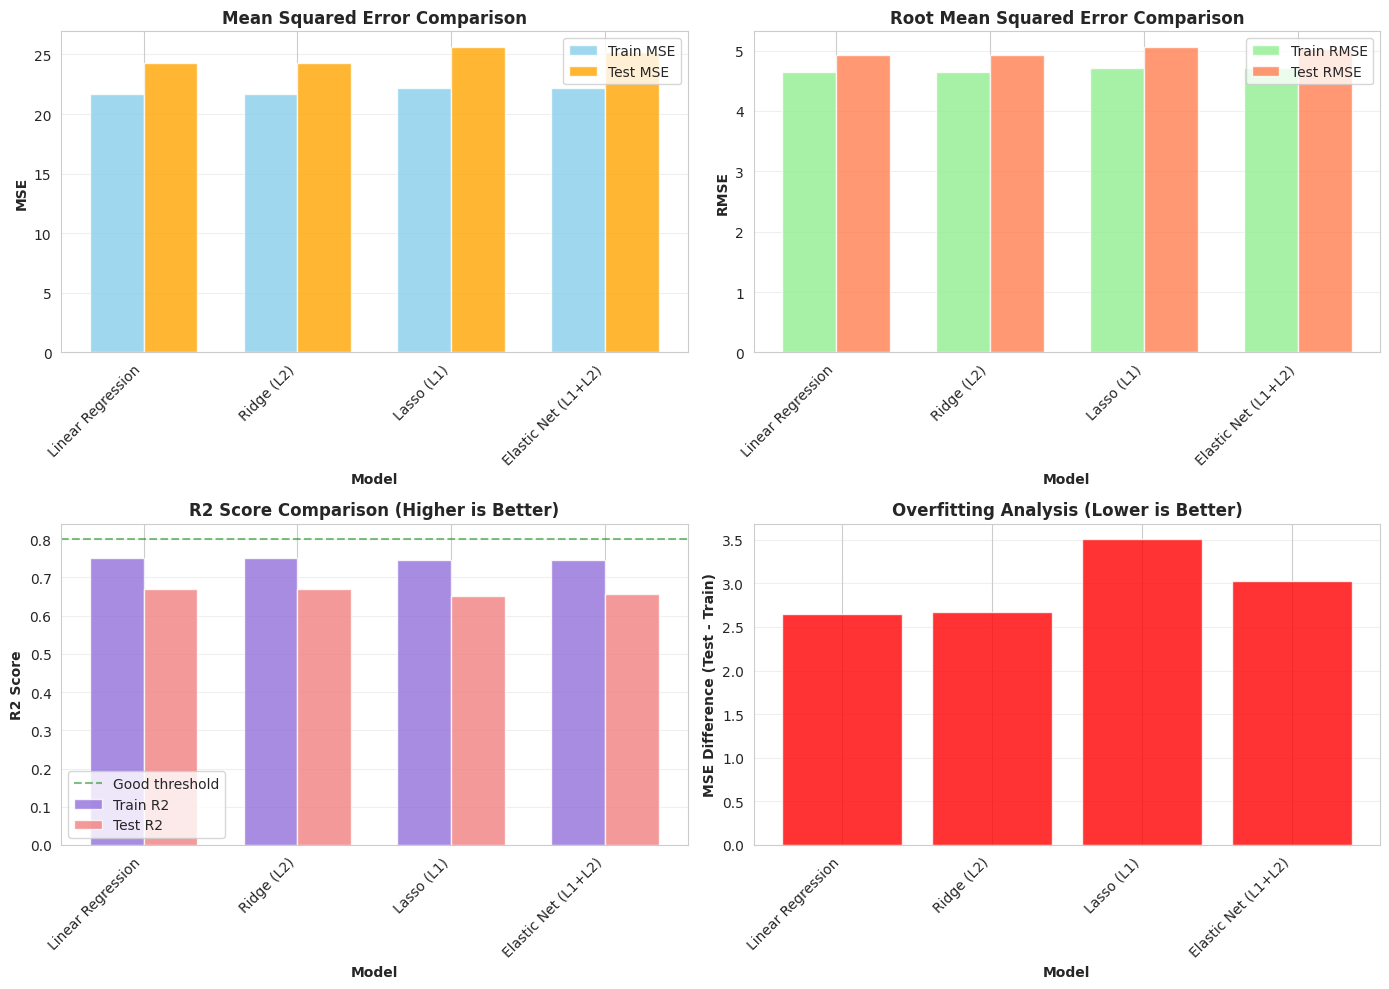

[COMPLETION] Visualization complete!


In [12]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. MSE Comparison
ax1 = axes[0, 0]
models = results_df['Model'].tolist()
x_pos = np.arange(len(models))
width = 0.35

ax1.bar(x_pos - width/2, results_df['Train MSE'], width, label='Train MSE', alpha=0.8, color='skyblue')
ax1.bar(x_pos + width/2, results_df['Test MSE'], width, label='Test MSE', alpha=0.8, color='orange')
ax1.set_xlabel('Model', fontweight='bold')
ax1.set_ylabel('MSE', fontweight='bold')
ax1.set_title('Mean Squared Error Comparison', fontweight='bold', fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. RMSE Comparison
ax2 = axes[0, 1]
ax2.bar(x_pos - width/2, results_df['Train RMSE'], width, label='Train RMSE', alpha=0.8, color='lightgreen')
ax2.bar(x_pos + width/2, results_df['Test RMSE'], width, label='Test RMSE', alpha=0.8, color='coral')
ax2.set_xlabel('Model', fontweight='bold')
ax2.set_ylabel('RMSE', fontweight='bold')
ax2.set_title('Root Mean Squared Error Comparison', fontweight='bold', fontsize=12)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. R2 Score Comparison
ax3 = axes[1, 0]
ax3.bar(x_pos - width/2, results_df['Train R2'], width, label='Train R2', alpha=0.8, color='mediumpurple')
ax3.bar(x_pos + width/2, results_df['Test R2'], width, label='Test R2', alpha=0.8, color='lightcoral')
ax3.set_xlabel('Model', fontweight='bold')
ax3.set_ylabel('R2 Score', fontweight='bold')
ax3.set_title('R2 Score Comparison (Higher is Better)', fontweight='bold', fontsize=12)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(models, rotation=45, ha='right')
ax3.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Good threshold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Overfitting Gap (Test - Train MSE)
ax4 = axes[1, 1]
overfitting_gap = results_df['Test MSE'] - results_df['Train MSE']
colors = ['green' if gap < 0.5 else 'orange' if gap < 2 else 'red' for gap in overfitting_gap]
ax4.bar(models, overfitting_gap, alpha=0.8, color=colors)
ax4.set_xlabel('Model', fontweight='bold')
ax4.set_ylabel('MSE Difference (Test - Train)', fontweight='bold')
ax4.set_title('Overfitting Analysis (Lower is Better)', fontweight='bold', fontsize=12)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax4.set_xticklabels(models, rotation=45, ha='right')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('[COMPLETION] Visualization complete!')

In [13]:
# Feature Coefficient Analysis
print('[FEATURE COEFFICIENT ANALYSIS]')
print('\nCompare how much each model trusts each feature\n')

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': lr.coef_,
    'Ridge (L2)': ridge.coef_,
    'Lasso (L1)': lasso.coef_,
    'Elastic Net': elasticnet.coef_
})

print(coef_df.to_string(index=False))

print('[OBSERVATIONS]')
print(f'1. Lasso zero coefficients: {(lasso.coef_ == 0).sum()} features eliminated')
print(f'2. Ridge keeps all features but with smaller magnitudes')
print(f'3. Elastic Net balances between elimination and shrinkage')

[FEATURE COEFFICIENT ANALYSIS]

Compare how much each model trusts each feature

Feature  Linear Regression  Ridge (L2)  Lasso (L1)  Elastic Net
   CRIM          -1.002135   -0.992187   -0.718365    -0.761221
     ZN           0.696269    0.677749    0.259627     0.322227
  INDUS           0.278065    0.252214   -0.000000    -0.031008
   CHAS           0.718738    0.722481    0.698221     0.736913
    NOX          -2.022319   -1.990835   -1.568142    -1.395953
     RM           3.145240    3.151572    3.271507     3.233606
    AGE          -0.176048   -0.177262   -0.000000    -0.096111
    DIS          -3.081908   -3.045029   -2.284449    -2.175919
    RAD           2.251407    2.173249    0.671938     0.846537
    TAX          -1.767014   -1.695559   -0.356654    -0.623952
PTRATIO          -2.037752   -2.027834   -1.893335    -1.830041
      B           1.129568    1.127197    1.031366     1.040336
  LSTAT          -3.611658   -3.598977   -3.609410    -3.403830
[OBSERVATIONS]
1. Lasso

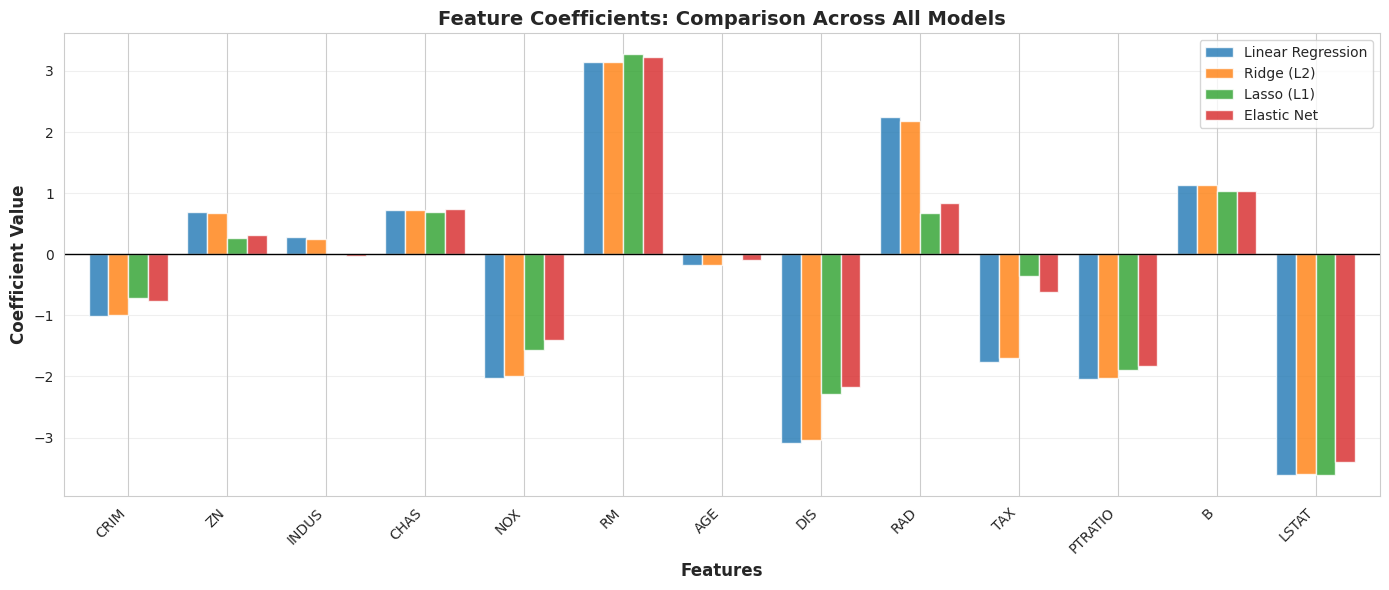

[RESULTS]
Coefficient visualization shows the importance each model assigns to features


In [14]:
# Visualize coefficients
fig, ax = plt.subplots(figsize=(14, 6))

coef_data = pd.DataFrame({
    'Linear Regression': lr.coef_,
    'Ridge (L2)': ridge.coef_,
    'Lasso (L1)': lasso.coef_,
    'Elastic Net': elasticnet.coef_
}, index=feature_names)

coef_data.plot(kind='bar', ax=ax, width=0.8, alpha=0.8)
ax.set_xlabel('Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title('Feature Coefficients: Comparison Across All Models', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('[RESULTS]')
print('Coefficient visualization shows the importance each model assigns to features')

---
# 7. LEARNING CURVES: DIAGNOSING BIAS-VARIANCE PROBLEMS

[GENERATING LEARNING CURVES]



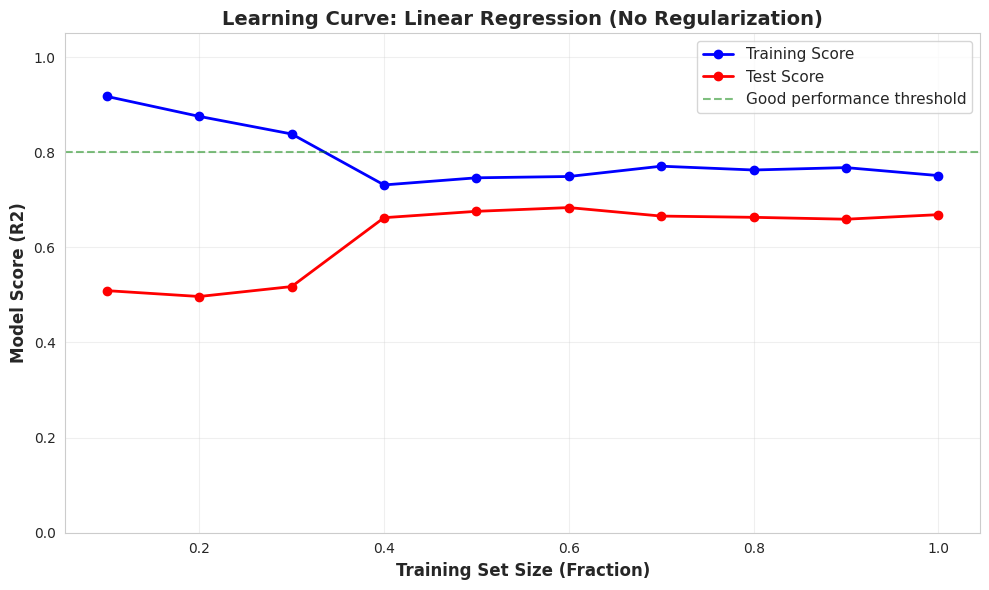

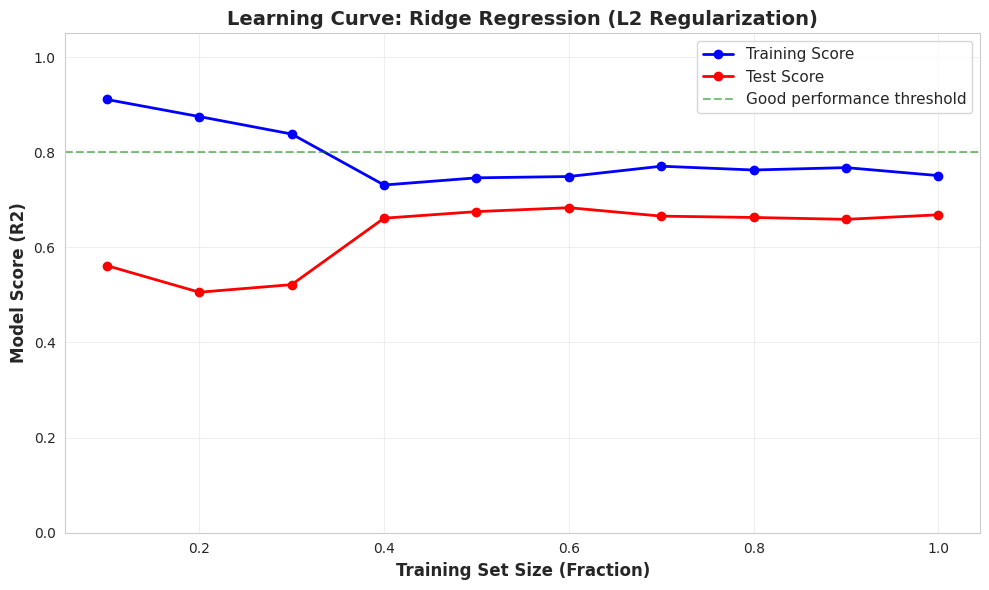

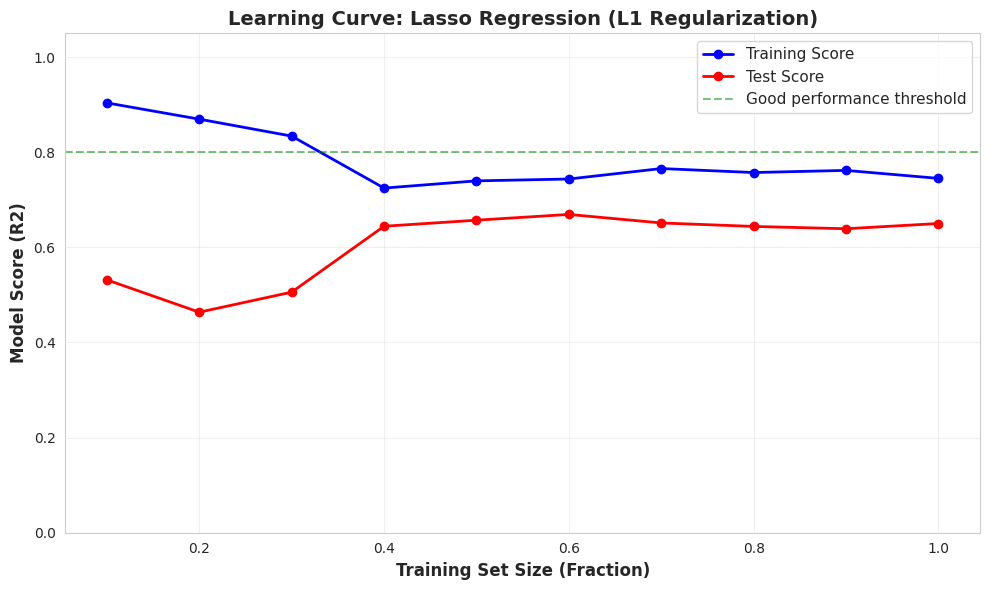

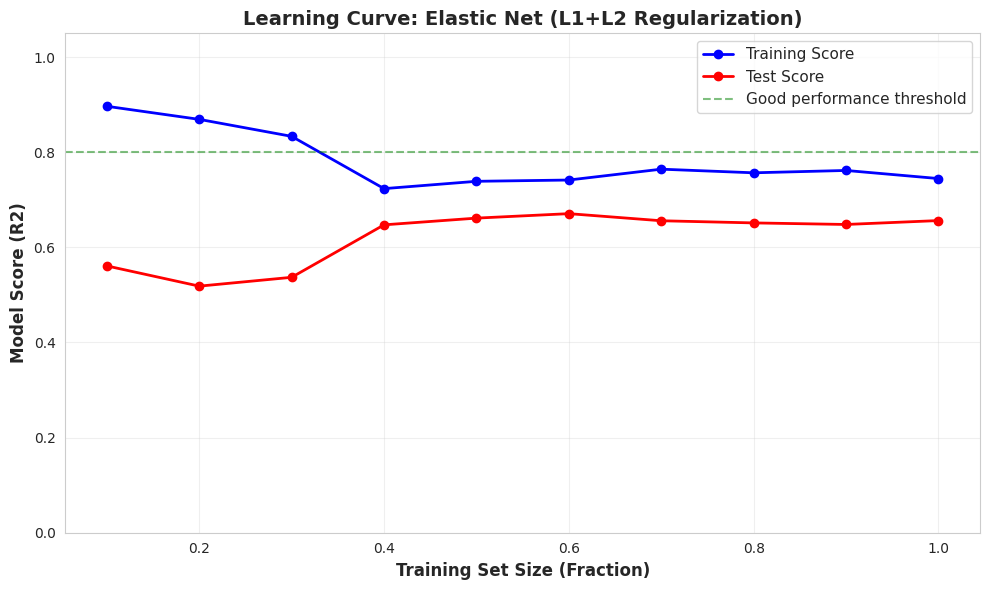

([0.8966082609315964,
  0.8691148977118938,
  0.8333818507527271,
  0.7234825127119084,
  0.7388650783895357,
  0.7415657018008758,
  0.7643845019966731,
  0.7567574999125626,
  0.7616864401484934,
  0.7446675500765167],
 [0.5609772568624211,
  0.5184556291611231,
  0.537027498083485,
  0.6473427195189039,
  0.6614786479589083,
  0.6708608392480426,
  0.6559269942877317,
  0.6514070991462086,
  0.6481230329615806,
  0.6563172951034018])

In [15]:
# Function to plot learning curves
def plot_learning_curve(model, X_train, X_test, y_train, y_test, model_name):
    train_sizes = np.linspace(0.1, 1.0, 10)
    train_scores = []
    test_scores = []

    for train_size in train_sizes:
        n_samples = int(len(X_train) * train_size)
        model.fit(X_train[:n_samples], y_train[:n_samples])

        train_score = model.score(X_train[:n_samples], y_train[:n_samples])
        test_score = model.score(X_test, y_test)

        train_scores.append(train_score)
        test_scores.append(test_score)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores, 'o-', linewidth=2, label='Training Score', color='blue', markersize=6)
    plt.plot(train_sizes, test_scores, 'o-', linewidth=2, label='Test Score', color='red', markersize=6)

    plt.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Good performance threshold')
    plt.xlabel('Training Set Size (Fraction)', fontsize=12, fontweight='bold')
    plt.ylabel('Model Score (R2)', fontsize=12, fontweight='bold')
    plt.title(f'Learning Curve: {model_name}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1.05])
    plt.tight_layout()
    plt.show()

    return train_scores, test_scores

print('[GENERATING LEARNING CURVES]')
print('')

# Plot learning curves for all models
plot_learning_curve(LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test, 'Linear Regression (No Regularization)')
plot_learning_curve(Ridge(alpha=1.0), X_train_scaled, X_test_scaled, y_train, y_test, 'Ridge Regression (L2 Regularization)')
plot_learning_curve(Lasso(alpha=0.1, max_iter=10000), X_train_scaled, X_test_scaled, y_train, y_test, 'Lasso Regression (L1 Regularization)')
plot_learning_curve(ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000), X_train_scaled, X_test_scaled, y_train, y_test, 'Elastic Net (L1+L2 Regularization)')

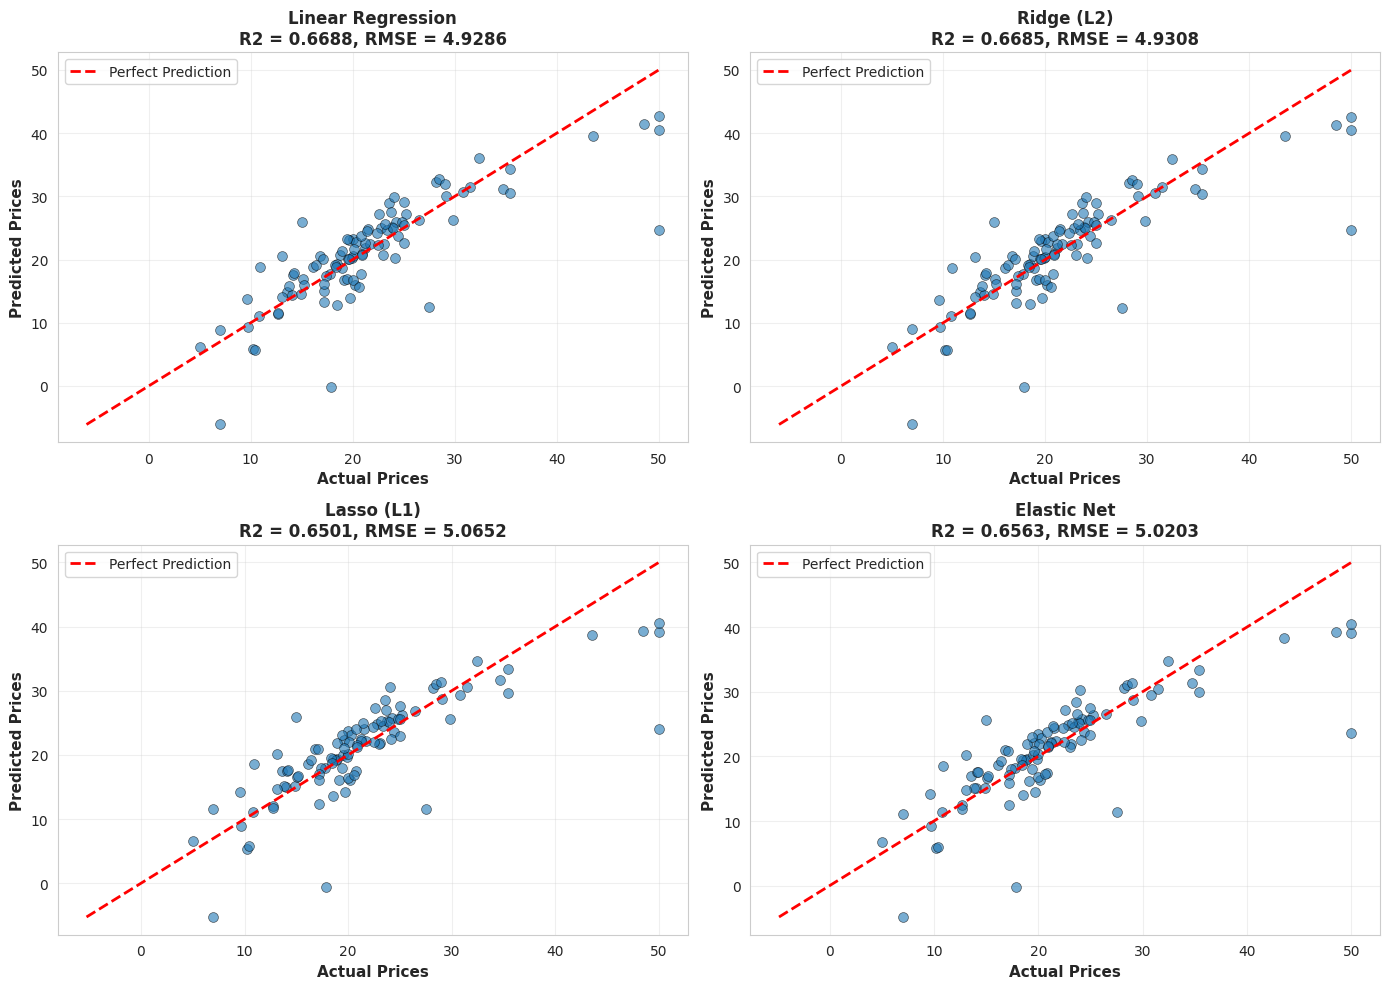

[COMPLETION]
Actual vs Predicted prices visualization complete!


In [16]:
# Predict on test set and visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_list = [
    (lr_test_pred, 'Linear Regression', axes[0, 0]),
    (ridge_test_pred, 'Ridge (L2)', axes[0, 1]),
    (lasso_test_pred, 'Lasso (L1)', axes[1, 0]),
    (en_test_pred, 'Elastic Net', axes[1, 1])
]

for predictions, title, ax in models_list:
    ax.scatter(y_test, predictions, alpha=0.6, s=50, edgecolors='k', linewidth=0.5)

    min_val = min(y_test.min(), predictions.min())
    max_val = max(y_test.max(), predictions.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    ax.set_xlabel('Actual Prices', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted Prices', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}\nR2 = {r2:.4f}, RMSE = {rmse:.4f}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('[COMPLETION]')
print('Actual vs Predicted prices visualization complete!')

---
# 8. SUMMARY & KEY TAKEAWAYS

## When to Use Each Model:

### 1. Linear Regression (No Regularization)
- Use when: Dataset is small, few features, no multicollinearity
- Avoid when: Many features, correlated features, overfitting observed

### 2. Ridge Regression (L2)
- Use when: Features are correlated, want to keep all features
- Handles multicollinearity better than Linear Regression
- Avoid when: Need automatic feature selection

### 3. Lasso Regression (L1)
- Use when: Need automatic feature selection, interpretability important
- Produces sparse models (many zero coefficients)
- Avoid when: Many correlated features (picks arbitrarily)

### 4. Elastic Net (L1 + L2)
- Use when: Want feature selection + handle multicollinearity
- Best general-purpose choice for most datasets
- Combines advantages of Ridge and Lasso

## Hyperparameter Tuning:
- **Alpha (lambda):** Regularization strength. Use cross-validation to find optimal value
- **L1_ratio:** For Elastic Net only. Balance between L1 (0.5 = 50/50, 1.0 = pure L1)

## Final Comparison Table

In [17]:
# Create comprehensive comparison table
comparison_data = {
    'Aspect': [
        'Penalty Term',
        'Feature Selection',
        'Sparse Solution',
        'Multicollinearity',
        'Interpretability',
        'Computational Cost',
        'Best For',
        'Hyperparameters'
    ],
    'Linear Regression': [
        'None',
        'No',
        'All coefficients',
        'Poor',
        'High',
        'Very Low',
        'Small, clean datasets',
        'None'
    ],
    'Ridge (L2)': [
        'lambda * Sigma(weights^2)',
        'No',
        'No',
        'Excellent',
        'Medium',
        'Low',
        'Correlated features',
        'Alpha (lambda)'
    ],
    'Lasso (L1)': [
        'lambda * Sigma(|weights|)',
        'Yes',
        'Yes (zeros)',
        'Poor',
        'High',
        'Medium',
        'Feature selection',
        'Alpha (lambda)'
    ],
    'Elastic Net': [
        'lambda * (alpha*|w| + (1-alpha)*w^2)',
        'Yes',
        'Partial',
        'Good',
        'High',
        'Medium',
        'Most real-world cases',
        'Alpha (lambda), L1_ratio (alpha)'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print('\n' + '='*120)
print('COMPREHENSIVE MODEL COMPARISON')
print('='*120)
print(comparison_df.to_string(index=False))


COMPREHENSIVE MODEL COMPARISON
            Aspect     Linear Regression                Ridge (L2)                Lasso (L1)                          Elastic Net
      Penalty Term                  None lambda * Sigma(weights^2) lambda * Sigma(|weights|) lambda * (alpha*|w| + (1-alpha)*w^2)
 Feature Selection                    No                        No                       Yes                                  Yes
   Sparse Solution      All coefficients                        No               Yes (zeros)                              Partial
 Multicollinearity                  Poor                 Excellent                      Poor                                 Good
  Interpretability                  High                    Medium                      High                                 High
Computational Cost              Very Low                       Low                    Medium                               Medium
          Best For Small, clean datasets       Correlated 

In [18]:
# Cross-validation scores
print('\n' + '='*80)
print('CROSS-VALIDATION ANALYSIS (5-Fold)')
print('='*80)
print('\nThis shows how models perform on different data splits\n')

models_cv = [
    ('Linear Regression', LinearRegression()),
    ('Ridge (L2)', Ridge(alpha=1.0)),
    ('Lasso (L1)', Lasso(alpha=0.1, max_iter=10000)),
    ('Elastic Net', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
]

for name, model in models_cv:
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    print(f'{name}:')
    print(f'   Fold Scores: {scores.round(4)}')
    print(f'   Mean Score: {scores.mean():.4f} (+/- {scores.std():.4f})')
    status = 'Stable' if scores.std() < 0.05 else 'Variable'
    print(f'   Status: {status}')
    print()


CROSS-VALIDATION ANALYSIS (5-Fold)

This shows how models perform on different data splits

Linear Regression:
   Fold Scores: [0.775  0.6242 0.7594 0.7877 0.6758]
   Mean Score: 0.7244 (+/- 0.0635)
   Status: Variable

Ridge (L2):
   Fold Scores: [0.7749 0.6243 0.7589 0.7883 0.6762]
   Mean Score: 0.7245 (+/- 0.0635)
   Status: Variable

Lasso (L1):
   Fold Scores: [0.7645 0.6207 0.7408 0.7951 0.6689]
   Mean Score: 0.7180 (+/- 0.0640)
   Status: Variable

Elastic Net:
   Fold Scores: [0.7677 0.6236 0.7425 0.7917 0.6741]
   Mean Score: 0.7199 (+/- 0.0622)
   Status: Variable



---
# 9. BEST PRACTICES FOR REGULARIZATION

## Best Practices:

1. **Always Standardize Features**
   - Regularization penalizes feature magnitudes
   - Use StandardScaler or MinMaxScaler
   - Without scaling, high-scale features are penalized more

2. **Use Cross-Validation for Hyperparameter Tuning**
   - Never tune on test set
   - Use GridSearchCV or RandomizedSearchCV
   - Try multiple alpha values: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

3. **Start with Elastic Net**
   - It is the most flexible and robust
   - Falls back to Ridge/Lasso if l1_ratio near 0 or 1
   - Good default choice for most problems

4. **Monitor Both Training and Test Errors**
   - Growing gap = overfitting
   - Both high = underfitting
   - Both low = good fit

5. **Interpret with Care**
   - Lasso coefficients are harder to interpret (selection bias)
   - Ridge coefficients are more stable but smaller in magnitude
   - Elastic Net offers balance

6. **Document Your Choices**
   - Why you chose this regularization
   - What alpha value was used
   - How hyperparameters were tuned

In [19]:
# Example: Hyperparameter tuning with cross-validation
from sklearn.model_selection import GridSearchCV

print('[HYPERPARAMETER TUNING EXAMPLE]')
print('='*80)

# Define parameter grid
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

# Perform grid search
print('[STATUS] Searching for optimal Elastic Net parameters...')
grid_search = GridSearchCV(
    ElasticNet(max_iter=10000),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print('[COMPLETION] Grid search complete!')
print(f'\nBest Parameters:')
print(f'   Alpha (lambda): {grid_search.best_params_["alpha"]}')
print(f'   L1 Ratio (alpha): {grid_search.best_params_["l1_ratio"]}')
print(f'   Best CV Score: {grid_search.best_score_:.4f}')

# Evaluate best model on test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test_scaled, y_test)
test_pred = best_model.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f'\nTest Set Performance:')
print(f'   Test R2 Score: {test_score:.4f}')
print(f'   Test RMSE: {test_rmse:.4f}')

[HYPERPARAMETER TUNING EXAMPLE]
[STATUS] Searching for optimal Elastic Net parameters...
[COMPLETION] Grid search complete!

Best Parameters:
   Alpha (lambda): 0.01
   L1 Ratio (alpha): 0.1
   Best CV Score: 0.7245

Test Set Performance:
   Test R2 Score: 0.6676
   Test RMSE: 4.9370


---
# 10. CONCLUSION & RECOMMENDATIONS

In [20]:
print('\n' + '='*80)
print('KEY TAKEAWAYS')
print('='*80)

summary_text = """
SUCCESS - WHAT WE LEARNED:

1. BIAS-VARIANCE TRADEOFF
   Every model has inherent bias and variance
   Goal is to find the sweet spot that minimizes total error
   Regularization helps control this tradeoff

2. L1 REGULARIZATION (LASSO)
   Adds penalty lambda * Sigma(|weights|)
   Shrinks less important coefficients to ZERO
   Best for feature selection and sparse models

3. L2 REGULARIZATION (RIDGE)
   Adds penalty lambda * Sigma(weights^2)
   Shrinks all coefficients proportionally
   Best for handling multicollinear features

4. ELASTIC NET (L1 + L2)
   Combines best of both L1 and L2
   Balances feature selection with coefficient shrinkage
   Most versatile choice for real-world problems

5. PRACTICAL IMPLEMENTATION
   Always standardize features before regularization
   Use cross-validation to tune hyperparameters
   Monitor train/test gap to detect overfitting
   Start simple, increase complexity as needed

BASED ON OUR HOUSING PREDICTION EXAMPLE:
"""

print(summary_text)

best_idx = results_df['Test R2'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_r2 = results_df.loc[best_idx, 'Test R2']
best_rmse = results_df.loc[best_idx, 'Test RMSE']

print(f'   Best Performing Model: {best_model_name}')
print(f'   Test R2: {best_r2:.4f}')
print(f'   Test RMSE: ${best_rmse:.2f}k')

recommendations = """
LEARNING RECOMMENDATIONS:
   1. Practice with different datasets
   2. Experiment with various alpha values
   3. Compare results with and without regularization
   4. Use GridSearchCV for production models
   5. Always validate on holdout test set

NEXT STEPS:
   1. Try on your own datasets
   2. Experiment with l1_ratio values in Elastic Net
   3. Implement early stopping with these models
   4. Combine with other techniques (PCA, feature engineering)
   5. Deploy in production with proper validation
"""

print(recommendations)
print('='*80)
print('\nCreated by: Mahipal Singh Sr - Instructor and Mentor DS/AI/ML')
print('\nThank you for learning with us! Keep practicing!')
print('='*80)


KEY TAKEAWAYS

SUCCESS - WHAT WE LEARNED:

1. BIAS-VARIANCE TRADEOFF
   Every model has inherent bias and variance
   Goal is to find the sweet spot that minimizes total error
   Regularization helps control this tradeoff

2. L1 REGULARIZATION (LASSO)
   Adds penalty lambda * Sigma(|weights|)
   Shrinks less important coefficients to ZERO
   Best for feature selection and sparse models

3. L2 REGULARIZATION (RIDGE)
   Adds penalty lambda * Sigma(weights^2)
   Shrinks all coefficients proportionally
   Best for handling multicollinear features

4. ELASTIC NET (L1 + L2)
   Combines best of both L1 and L2
   Balances feature selection with coefficient shrinkage
   Most versatile choice for real-world problems

5. PRACTICAL IMPLEMENTATION
   Always standardize features before regularization
   Use cross-validation to tune hyperparameters
   Monitor train/test gap to detect overfitting
   Start simple, increase complexity as needed

BASED ON OUR HOUSING PREDICTION EXAMPLE:

   Best Perform

---

## References & Further Reading

- Scikit-learn Documentation: https://scikit-learn.org/
- Elements of Statistical Learning: Hastie, Tibshirani, Friedman
- Machine Learning Yearning: Andrew Ng
- Hands-On Machine Learning: Aurelien Geron

---

## Credits

**Created by:** Mahipal Singh Sr  
**Title:** Instructor and Mentor - Data Science, AI & ML  
**Purpose:** Educational resource for comprehensive understanding of regularization in machine learning  
**Date:** 2024